<a href="https://colab.research.google.com/github/idouglas237020/CS4410/blob/main/Ingram_Douglas_Homework_6_Exercise12_6_Hamlet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Homework 6 - Exercise 12.6

Word Frequency Bar Chart and Word Cloud from Shakespeare's Hamlet

This program downloads Shakespeare's Hamlet, analyzes the frequency of words,
displays the 20 most common words in a bar chart, and creates a word cloud
using an oval mask.

In [22]:
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [23]:
import requests
import re
import pandas as pd
import matplotlib.pyplot as plt
import imageio.v3 as iio

from textblob import TextBlob
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud

In [24]:
target_url = 'https://www.gutenberg.org/files/2265/2265-0.txt'

response = requests.get(target_url)
data = response.text

print(data[:1000])

*** START OF THE PROJECT GUTENBERG EBOOK 2265 ***


Executive Director's Notes:

In addition to the notes below, and so you will *NOT* think all
the spelling errors introduced by the printers of the time have
been corrected, here are the first few lines of Hamlet, as they
are presented herein:

  Barnardo. Who's there?
  Fran. Nay answer me: Stand & vnfold
your selfe

   Bar. Long liue the King

       *       *       *       *       *

As I understand it, the printers often ran out of certain words
or letters they had often packed into a "cliche". . .this is the
original meaning of the term cliche. . .and thus, being unwilling
to unpack the cliches, and thus you will see some substitutions
that look very odd. . .such as the exchanges of u for v, v for u,
above. . .and you may wonder why they did it this way, presuming
Shakespeare did not actually write the play in this manner. . . .

The answer is that they MAY have packed "liue" into a cliche at a
time when


In [25]:
blob = TextBlob(data)

print("Number of characters:", len(data))
print("Number of words:", len(blob.words))

Number of characters: 171696
Number of words: 30737


In [26]:
stop_words = set(stopwords.words('english'))

words = [
    word.lower()
    for word in blob.words
    if word.isalpha() and word.lower() not in stop_words
]

word_counts = Counter(words)

In [27]:
top_20 = word_counts.most_common(20)

top_20

[('ham', 337),
 ('lord', 211),
 ('haue', 175),
 ('king', 173),
 ('shall', 107),
 ('come', 106),
 ('thou', 105),
 ('let', 104),
 ('hamlet', 100),
 ('good', 98),
 ('hor', 95),
 ('thy', 90),
 ('enter', 85),
 ('oh', 81),
 ('like', 78),
 ('well', 70),
 ('may', 69),
 ('know', 69),
 ('selfe', 68),
 ('would', 68)]

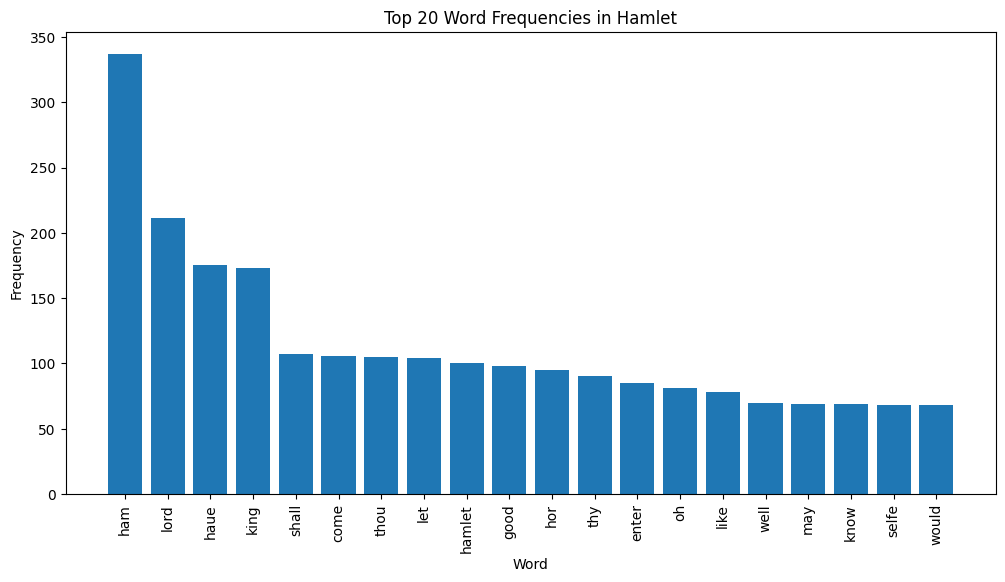

In [28]:
words_20 = [item[0] for item in top_20]
counts_20 = [item[1] for item in top_20]

plt.figure(figsize=(12, 6))
plt.bar(words_20, counts_20)

plt.title("Top 20 Word Frequencies in Hamlet")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=90)

plt.show()

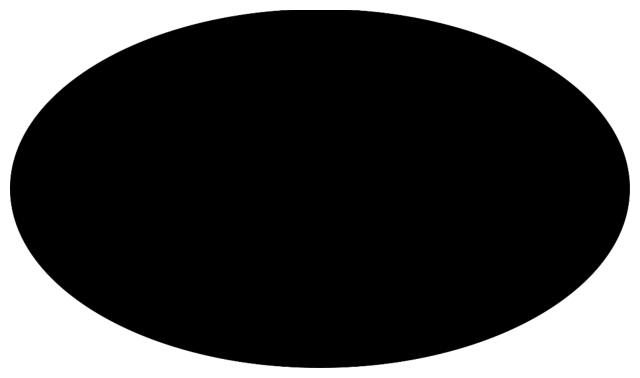

In [29]:
import imageio.v3 as iio

mask_image = iio.imread('/content/mask_oval.png')

plt.figure(figsize=(8, 6))
plt.imshow(mask_image)
plt.axis('off')
plt.show()

In [30]:
wordcloud = WordCloud(
    width=1000,
    height=700,
    background_color='white',
    stopwords=stop_words,
    mask=mask_image,
    max_words=200,
    colormap='hsv'
).generate(data)

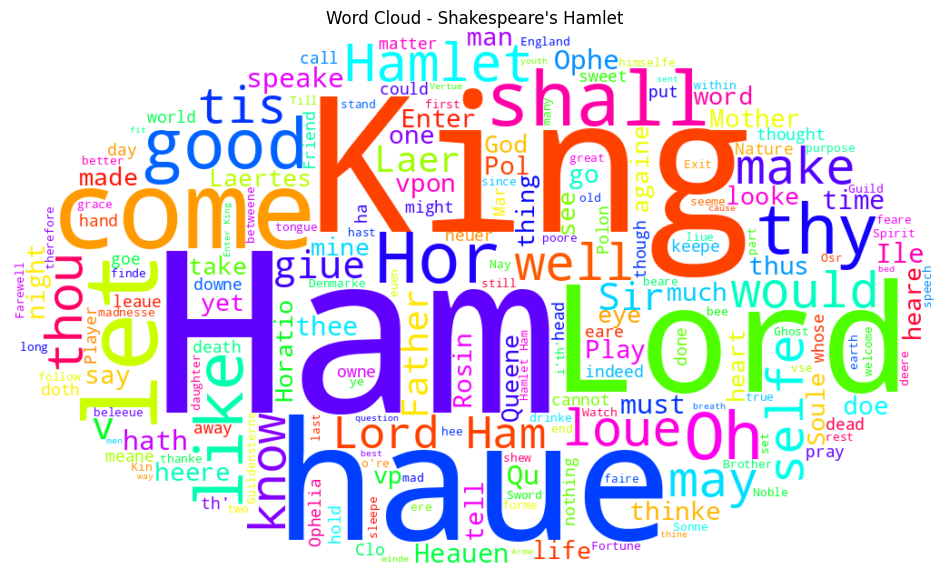

In [31]:
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Shakespeare's Hamlet")
plt.show()

Conclusion

The word-frequency analysis identifies the words that occur most often in
Shakespeare's Hamlet. The bar chart provides a numerical comparison of the
20 most frequent non-stop words, while the word cloud provides a visual
representation in which more frequently occurring words appear larger.